<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_svm_classification_regression_kernels_hyperparameter_visualization_2d_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Basic SVM (Classification) — Scikit-learn**

In [31]:
# Step 1: Import libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Step 2: Load dataset (Iris example)
data = datasets.load_iris()
X = data.data
y = data.target

# Step 3: Train-test split
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Create SVM model
model = SVC(kernel='linear')  # You can change kernel

# Step 5: Train model
model.fit(X_train_original, y_train)

# Step 6: Predict
y_pred = model.predict(X_test_original)

# Step 7: Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# **2. Different Kernels**

In [32]:
# Linear
SVC(kernel='linear')

# Polynomial
SVC(kernel='poly', degree=3)

# RBF (most powerful in real-world)
SVC(kernel='rbf')

# Sigmoid
SVC(kernel='sigmoid')

SVC(kernel='sigmoid')

# **3. SVM with Hyperparameter Tuning**

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train_original, y_train)

print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01,

# **4. SVM for Regression (SVR)**

In [34]:
from sklearn.svm import SVR

model = SVR(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# **5. Scaling**

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **6. Real-World Template**

In [36]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# **1. Full SVM Visualization (2D Data)**

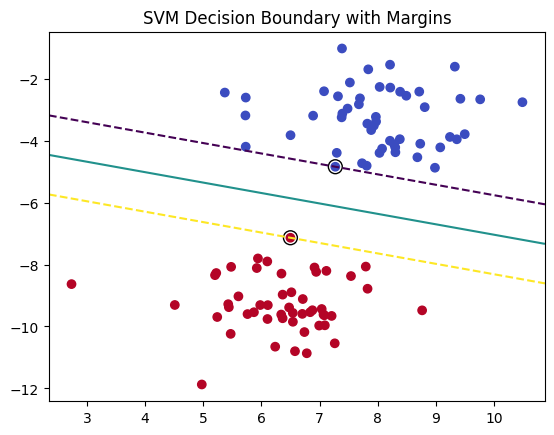

In [37]:
# svm_visualization.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load dataset (2D for visualization)
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=6)

# Train SVM
model = SVC(kernel='linear', C=1)
model.fit(X, y)

# Plot function
def plot_svm(model, X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # decision boundary and margins
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])

    # support vectors
    ax.scatter(model.support_vectors_[:, 0],
               model.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')

    plt.title("SVM Decision Boundary with Margins")
    plt.show()

plot_svm(model, X, y)

# **2. Visualizing Effect of C (Regularization)**

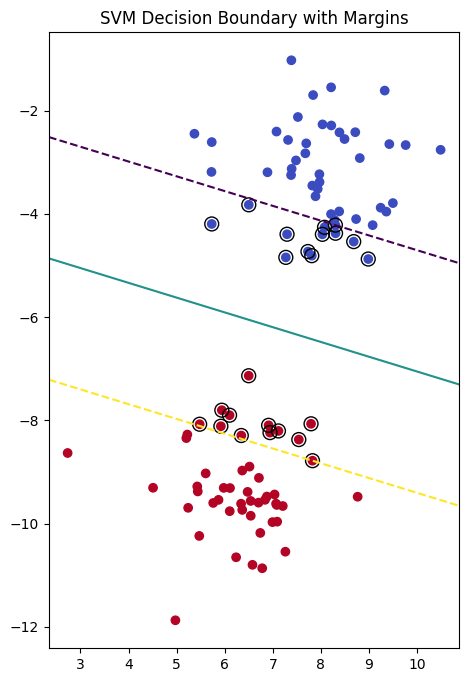

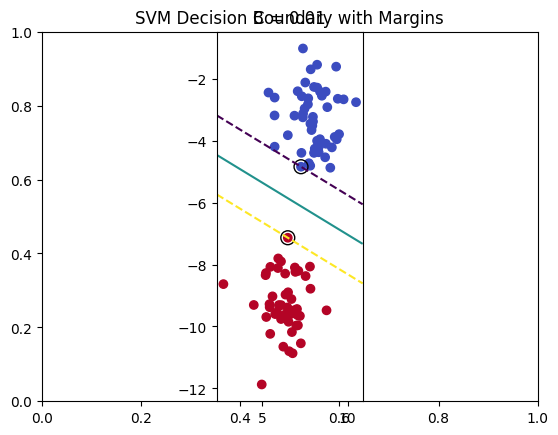

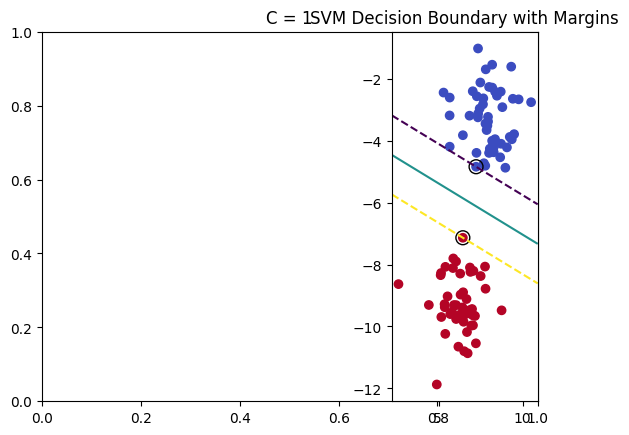

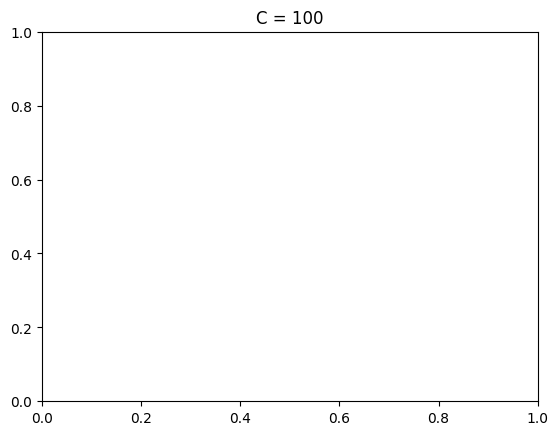

In [38]:
C_values = [0.01, 1, 100]

plt.figure(figsize=(18, 8))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    plt.subplot(1, 3, i+1)
    plot_svm(model, X, y)
    plt.title(f"C = {C}")

plt.show()

# **3. Visualizing Non-Linear SVM (RBF Kernel)**

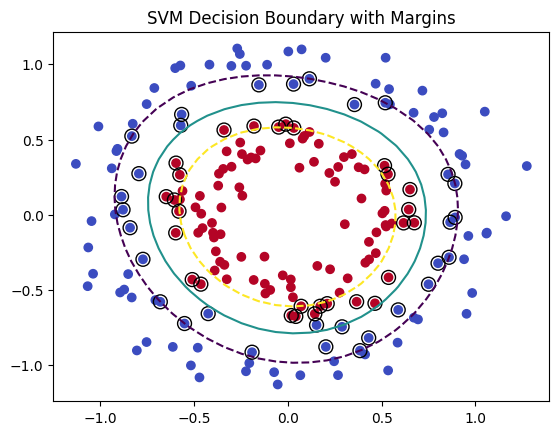

In [39]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=200, factor=0.5, noise=0.1)

model = SVC(kernel='rbf', gamma=1)
model.fit(X, y)

plot_svm(model, X, y)

# **4. Gamma Effect**

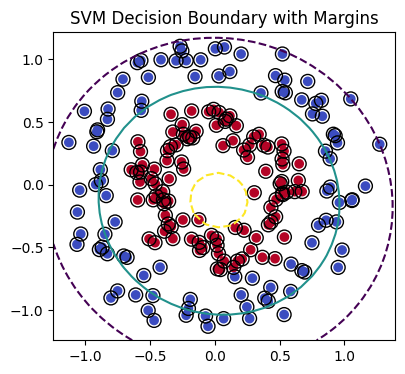

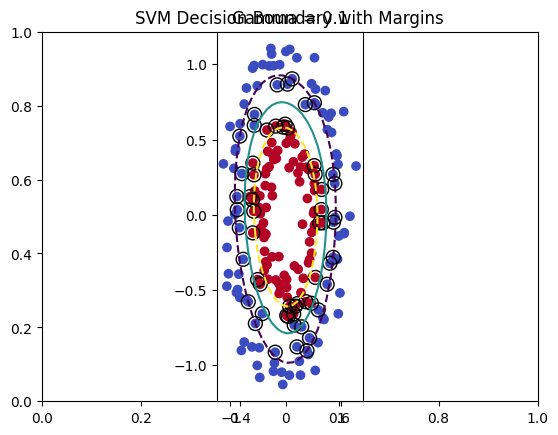

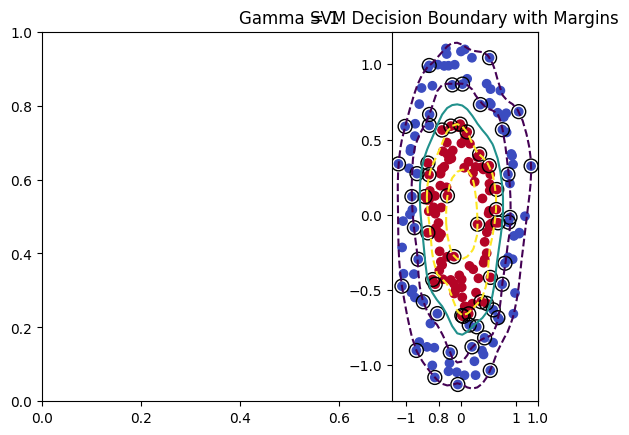

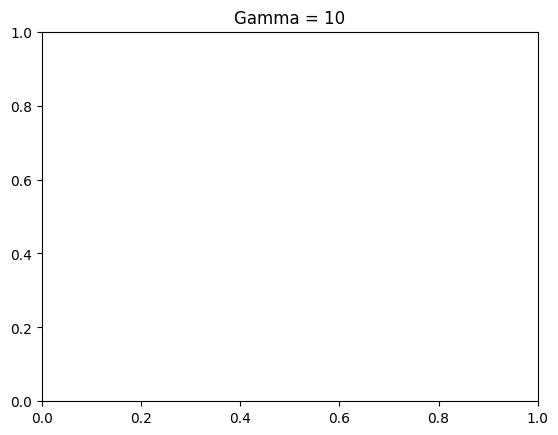

In [40]:
gamma_values = [0.1, 1, 10]

plt.figure(figsize=(15, 4))

for i, g in enumerate(gamma_values):
    model = SVC(kernel='rbf', gamma=g)
    model.fit(X, y)

    plt.subplot(1, 3, i+1)
    plot_svm(model, X, y)
    plt.title(f"Gamma = {g}")

plt.show()

# **5. Animated Decision Boundary**

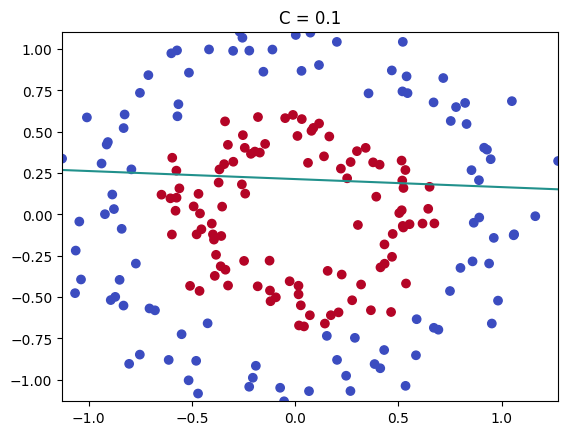

In [41]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    model = SVC(kernel='linear', C=frame)
    model.fit(X, y)

    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[-1, 0, 1])
    ax.set_title(f"C = {frame}")

ani = animation.FuncAnimation(fig, update, frames=[0.1, 1, 10, 50], repeat=False)

# To display the animation in Colab, save it as an HTML object
# and then display it using IPython.display.HTML
html_animation = HTML(ani.to_jshtml())

# We need to explicitly return the HTML object to display it in a Colab notebook
html_animation

# **6. Best Practice**

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma=0.1))
])

pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=1, gamma=0.1))])

In [43]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# 2. Generate a synthetic 3D dataset for classification
X_3d, y_3d = make_blobs(n_samples=200, centers=2, n_features=3, random_state=42, cluster_std=1.5)

print(f"Shape of X_3d: {X_3d.shape}")
print(f"Shape of y_3d: {y_3d.shape}")

# 3. Create an instance of the SVC model with a linear kernel
svm_3d_model = SVC(kernel='linear', random_state=42)

# 4. Fit the linear SVM model to the generated 3D dataset
svm_3d_model.fit(X_3d, y_3d)
print("Linear SVM model trained on 3D data successfully.")

Shape of X_3d: (200, 3)
Shape of y_3d: (200,)
Linear SVM model trained on 3D data successfully.


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage.measure import marching_cubes

def plot_svm_3d(model, X, y, title="", plot_support_vectors=True):
    """
    Plots 3D data points and the SVM decision boundary as a surface.

    Args:
        model: Trained SVM model (SVC).
        X: 3D features array.
        y: Target labels array.
        title (str): Title for the plot.
        plot_support_vectors (bool): Whether to plot support vectors.
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Plot the data points
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', s=50, alpha=0.8, label='Data Points')

    # 4. Plot support vectors
    if plot_support_vectors and hasattr(model, 'support_vectors_'):
        if model.support_vectors_.shape[1] == 3: # Ensure support vectors are 3D
            ax.scatter(model.support_vectors_[:, 0],
                       model.support_vectors_[:, 1],
                       model.support_vectors_[:, 2],
                       s=200, facecolors='none', edgecolors='k', marker='o', linewidth=2, label='Support Vectors')

    # 5. Visualize the decision boundary as a surface
    # Determine min/max for each dimension with a margin
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    z_min, z_max = X[:, 2].min() - 1, X[:, 2].max() + 1

    # Create a 3D meshgrid
    num_points = 40 # Resolution for the grid
    xx = np.linspace(x_min, x_max, num_points)
    yy = np.linspace(y_min, y_max, num_points)
    zz = np.linspace(z_min, z_max, num_points)
    XX, YY, ZZ = np.meshgrid(xx, yy, zz)

    # Reshape meshgrid for decision_function
    xyz = np.vstack([XX.ravel(), YY.ravel(), ZZ.ravel()]).T

    # Compute decision function values
    try:
        values = model.decision_function(xyz).reshape(XX.shape)
    except AttributeError:
        print("Warning: decision_function not available or failed for the model. Cannot plot boundary.")
        plt.show()
        return

    # Extract isosurface using marching_cubes
    verts, faces, _, _ = marching_cubes(values, level=0) # level=0 for the decision boundary

    # Scale vertices from grid indices to actual data coordinates
    verts_scaled = np.empty_like(verts)
    verts_scaled[:, 0] = x_min + verts[:, 0] * (x_max - x_min) / (num_points - 1)
    verts_scaled[:, 1] = y_min + verts[:, 1] * (y_max - y_min) / (num_points - 1)
    verts_scaled[:, 2] = z_min + verts[:, 2] * (z_max - z_min) / (num_points - 1)

    # Plot the extracted isosurface
    ax.plot_trisurf(verts_scaled[:, 0], verts_scaled[:, 1], verts_scaled[:, 2],
                    triangles=faces, cmap='viridis', alpha=0.4, linewidth=0.1, edgecolor='none', label='Decision Boundary')

    # Add arrow for normal vector if it's a linear kernel
    if hasattr(model, 'coef_') and model.coef_.shape[1] == 3 and model.kernel == 'linear':
        w = model.coef_[0]
        b = model.intercept_[0]

        # Calculate a point on the hyperplane to draw the normal from
        x_mean = np.mean(X, axis=0)
        point_on_hyperplane = x_mean - (np.dot(w, x_mean) + b) / np.dot(w, w) * w

        # Determine a suitable length for the arrow for visualization
        data_range = np.max(X, axis=0) - np.min(X, axis=0)
        max_dim_range = np.max(data_range)
        arrow_display_length = max_dim_range * 0.2 # 20% of the largest data range dimension

        ax.quiver(point_on_hyperplane[0], point_on_hyperplane[1], point_on_hyperplane[2],
                  w[0], w[1], w[2],
                  color='red', length=arrow_display_length, normalize=True,
                  arrow_length_ratio=0.3, label='Hyperplane Normal')

    # 6. Set labels and title
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title(title)

    # Add a legend for clarity if labels were provided
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    # 7. Display the plot
    plt.show()

print("plot_svm_3d function defined successfully.")

plot_svm_3d function defined successfully.


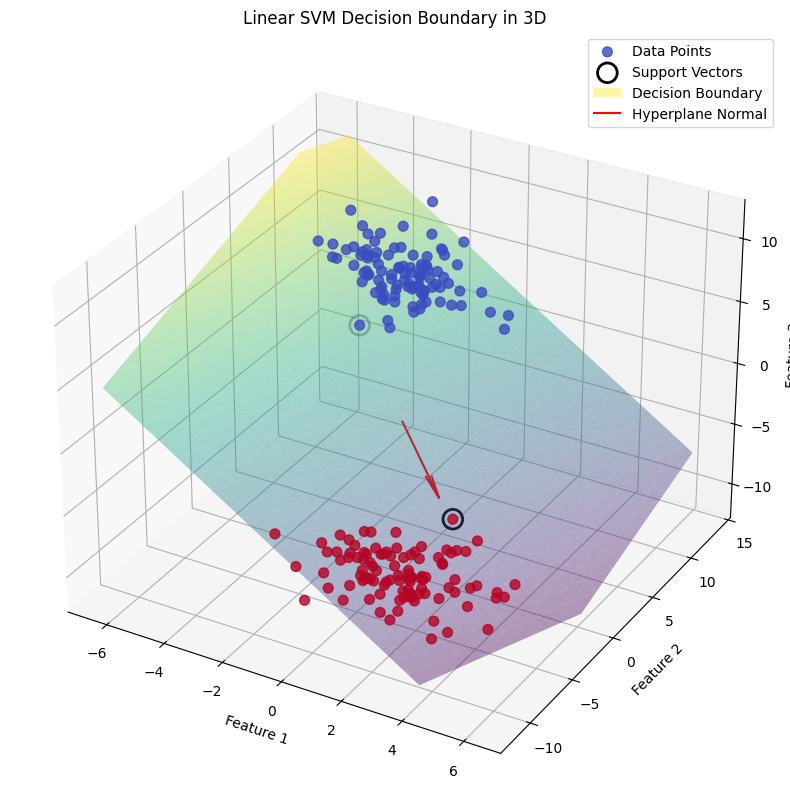

In [55]:
plot_svm_3d(svm_3d_model, X_3d, y_3d, title='Linear SVM Decision Boundary in 3D')

Shape of X_nonlinear_3d: (200, 3)
Shape of y_nonlinear_3d: (200,)
RBF SVM model trained on non-linear 3D data successfully.


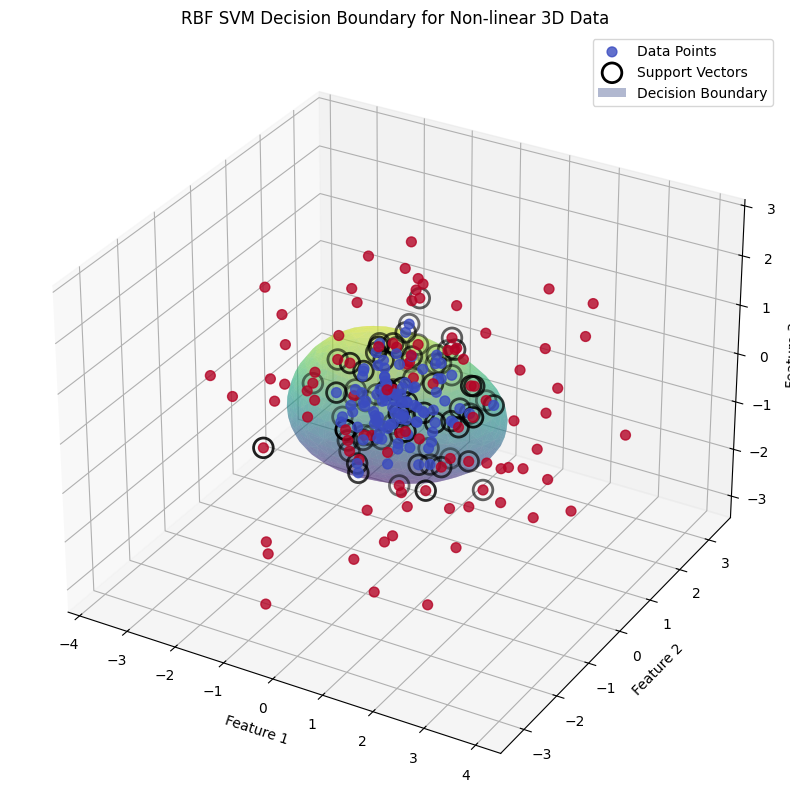

In [48]:
import numpy as np
from sklearn.svm import SVC

# 1. Generate a synthetic 3D non-linearly separable dataset (concentric-like spheres)
n_samples = 200

# Inner sphere-like cluster
X_inner = np.random.randn(n_samples // 2, 3) * 0.5  # Smaller spread
y_inner = np.zeros(n_samples // 2)

# Outer sphere-like cluster
X_outer = np.random.randn(n_samples // 2, 3) * 1.5  # Larger spread
y_outer = np.ones(n_samples // 2)

# Combine and shuffle the data
X_nonlinear_3d = np.vstack((X_inner, X_outer))
y_nonlinear_3d = np.hstack((y_inner, y_outer))

# Shuffle data to ensure randomness
indices = np.arange(n_samples)
np.random.shuffle(indices)
X_nonlinear_3d = X_nonlinear_3d[indices]
y_nonlinear_3d = y_nonlinear_3d[indices]

print(f"Shape of X_nonlinear_3d: {X_nonlinear_3d.shape}")
print(f"Shape of y_nonlinear_3d: {y_nonlinear_3d.shape}")

# 2. Create an instance of the SVC model with an RBF kernel
rbf_svm_3d_model = SVC(kernel='rbf', gamma='scale', C=1, random_state=42)

# 3. Fit this RBF SVM model to the newly generated 3D dataset
rbf_svm_3d_model.fit(X_nonlinear_3d, y_nonlinear_3d)
print("RBF SVM model trained on non-linear 3D data successfully.")

# 4. Call the plot_svm_3d function to visualize the decision boundary
plot_svm_3d(rbf_svm_3d_model, X_nonlinear_3d, y_nonlinear_3d, title='RBF SVM Decision Boundary for Non-linear 3D Data')

Visualizing Linear SVM with different C values:


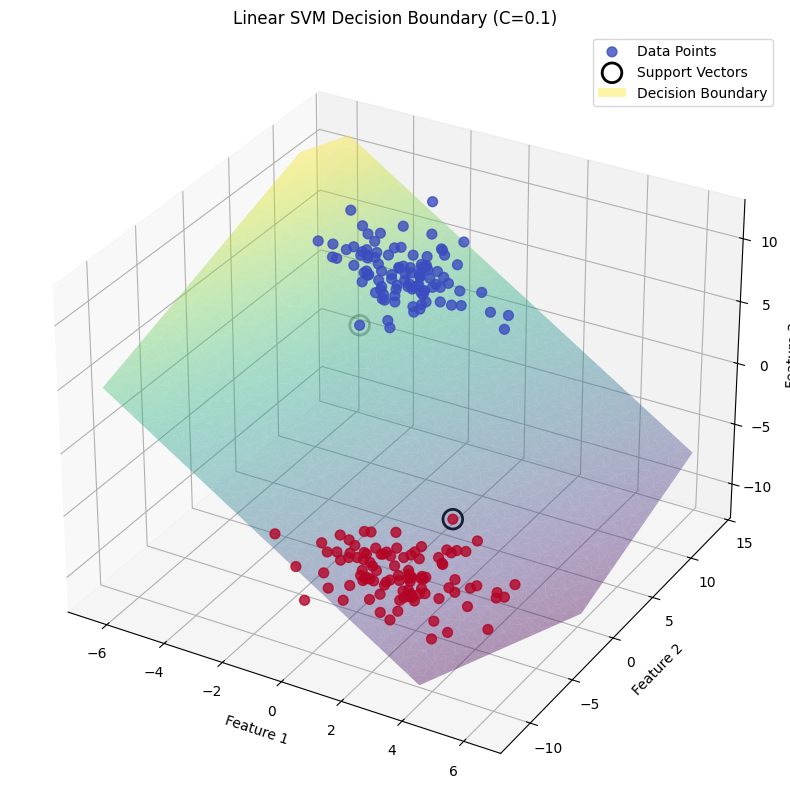

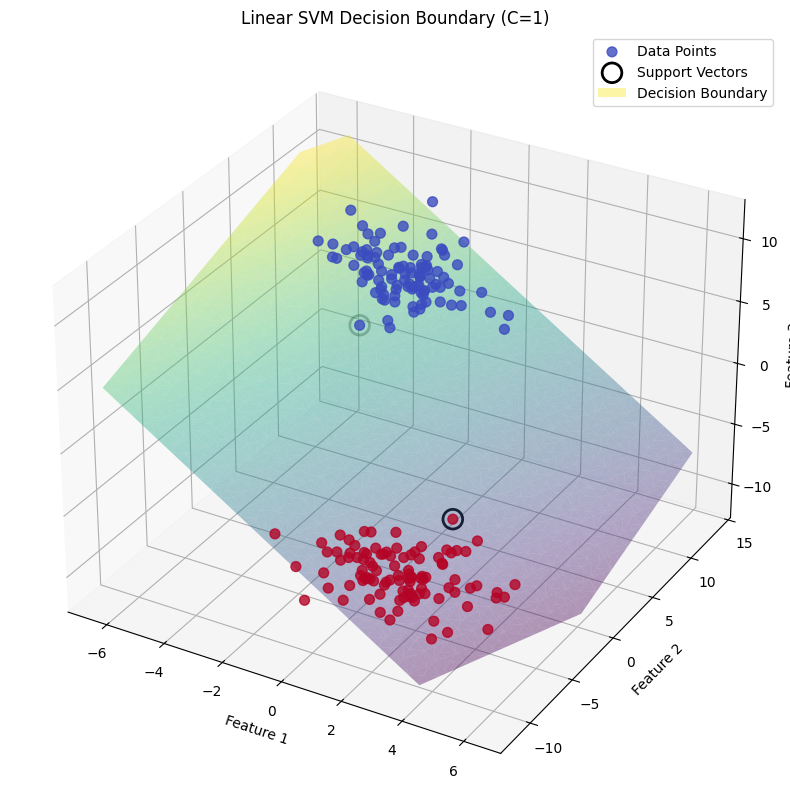

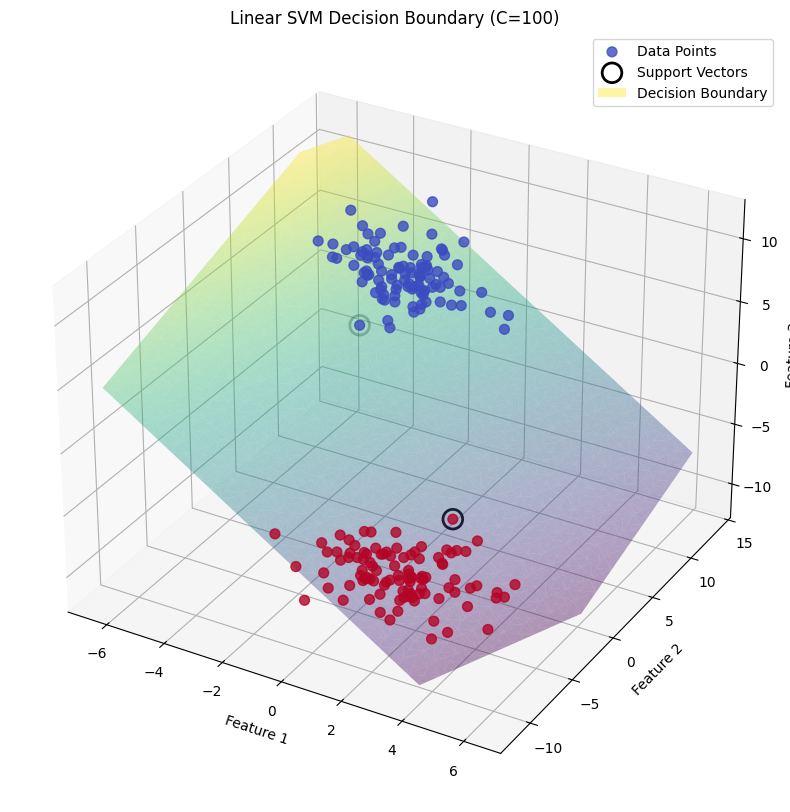

Linear SVM C-value visualization complete.


In [49]:
C_values = [0.1, 1, 100]

print("Visualizing Linear SVM with different C values:")
for C in C_values:
    # Initialize an SVC model with a linear kernel and the current C value
    linear_svm_c_model = SVC(kernel='linear', C=C, random_state=42)

    # Fit the linear SVM model to the 3D dataset
    linear_svm_c_model.fit(X_3d, y_3d)

    # Call the plot_svm_3d function to visualize the decision boundary
    plot_svm_3d(linear_svm_c_model, X_3d, y_3d, title=f'Linear SVM Decision Boundary (C={C})')

print("Linear SVM C-value visualization complete.")

Visualizing RBF SVM with different C values:


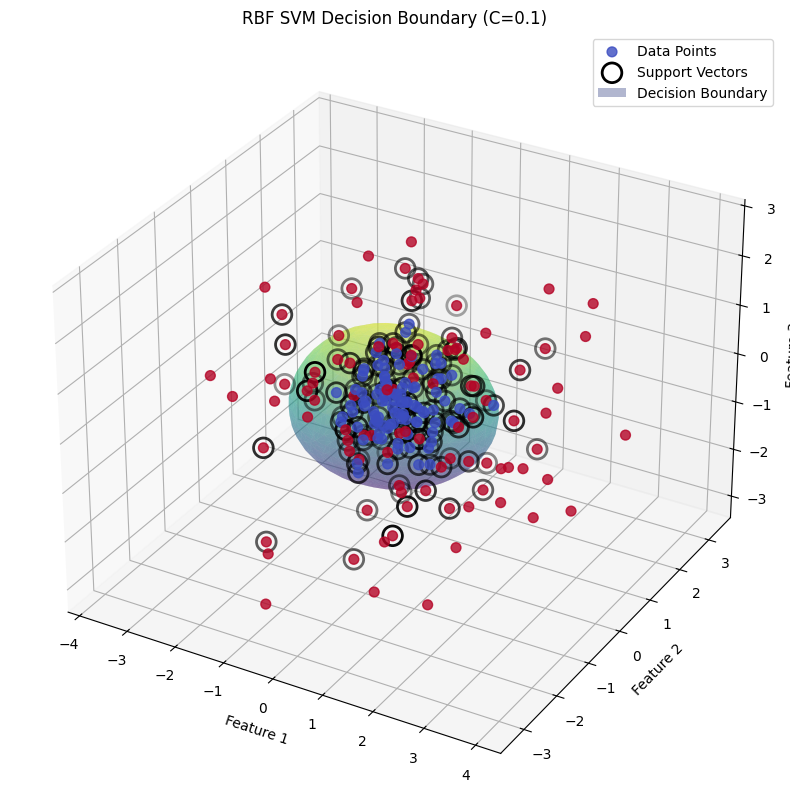

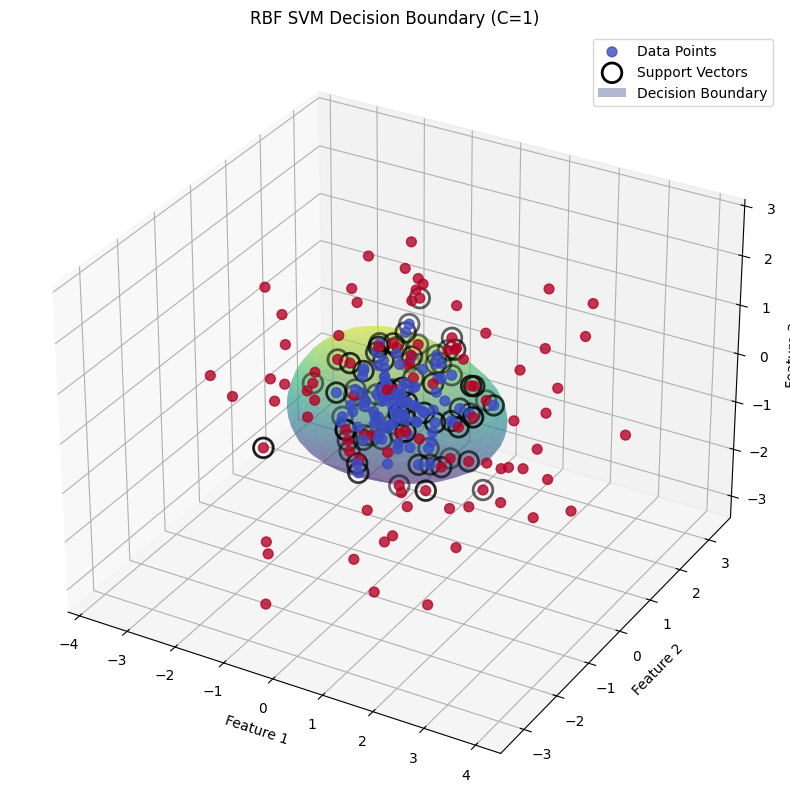

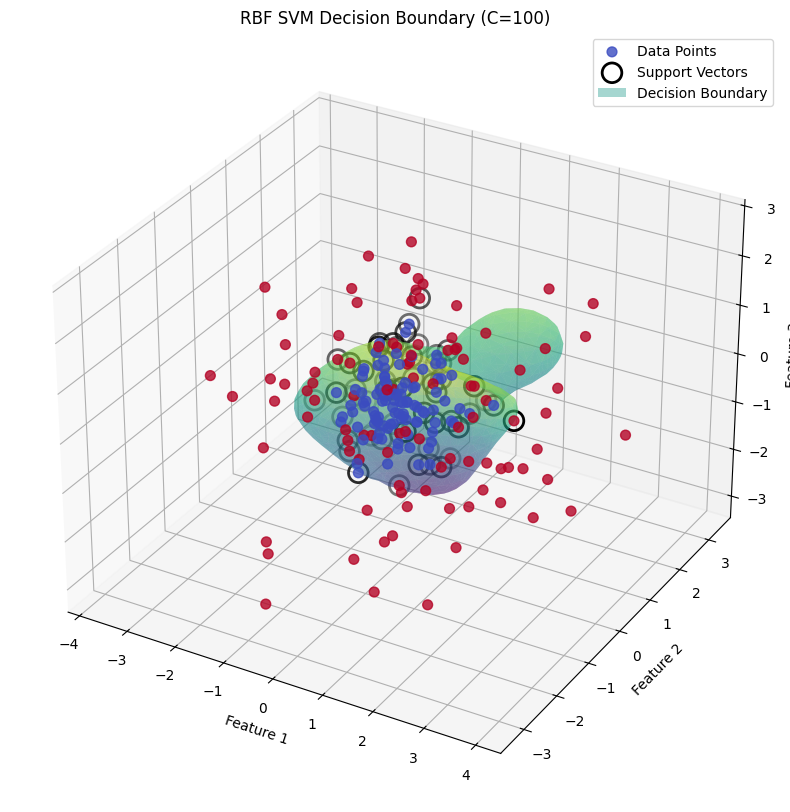

RBF SVM C-value visualization complete.


In [50]:
print("Visualizing RBF SVM with different C values:")
for C in C_values:
    # Initialize an SVC model with an RBF kernel, gamma='scale', and the current C value
    rbf_svm_c_model = SVC(kernel='rbf', gamma='scale', C=C, random_state=42)

    # Fit the RBF SVM model to the non-linear 3D dataset
    rbf_svm_c_model.fit(X_nonlinear_3d, y_nonlinear_3d)

    # Call the plot_svm_3d function to visualize the decision boundary
    plot_svm_3d(rbf_svm_c_model, X_nonlinear_3d, y_nonlinear_3d, title=f'RBF SVM Decision Boundary (C={C})')

print("RBF SVM C-value visualization complete.")

Visualizing RBF SVM with different gamma values:


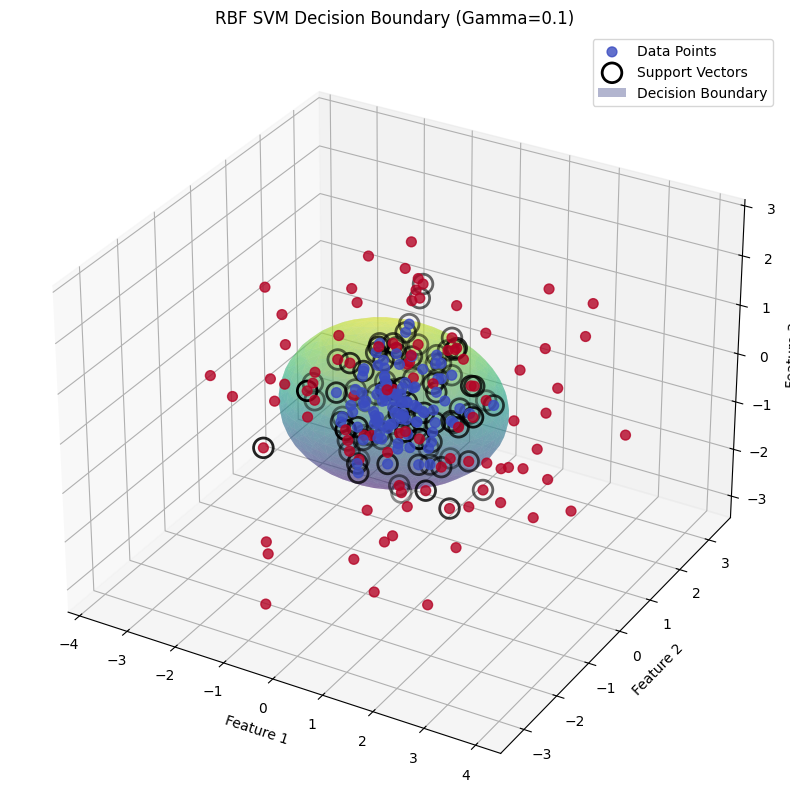

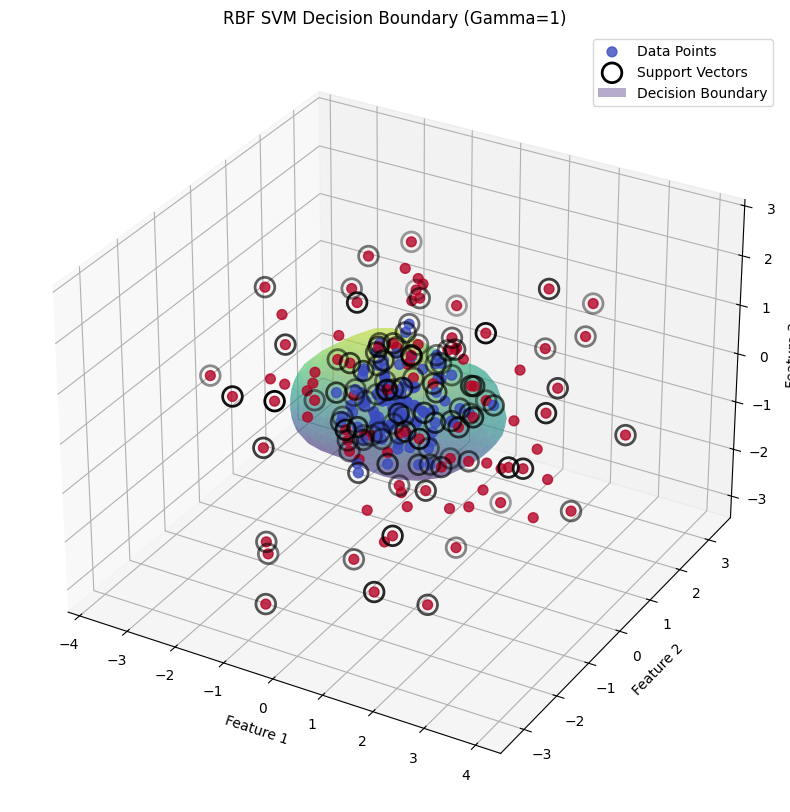

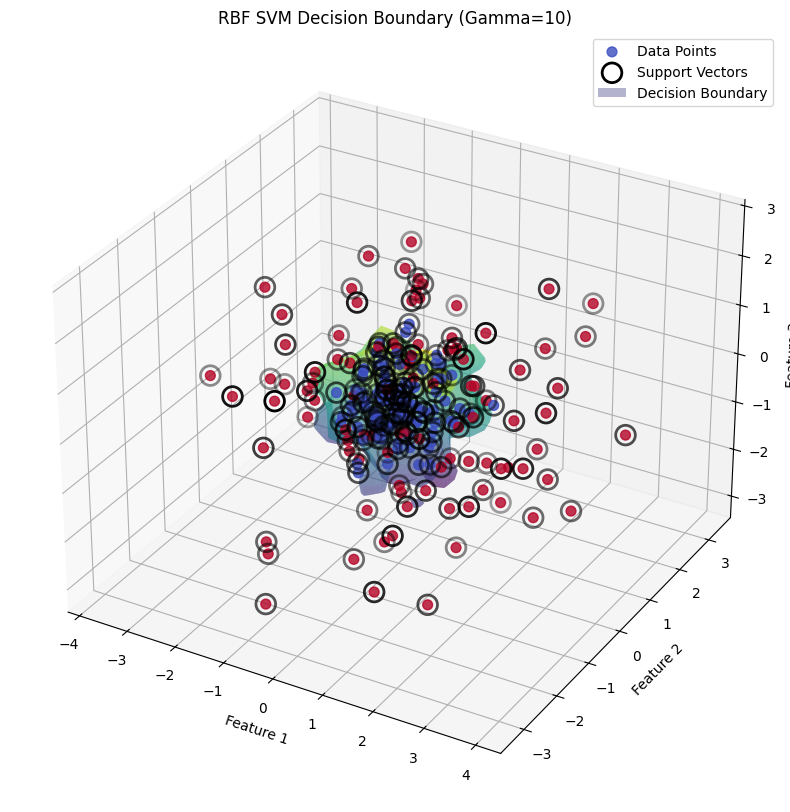

RBF SVM gamma-value visualization complete.


In [51]:
gamma_values = [0.1, 1, 10]

print("Visualizing RBF SVM with different gamma values:")
for g in gamma_values:
    # Create an instance of the SVC model with an RBF kernel, C=1, and the current gamma value
    rbf_svm_gamma_model = SVC(kernel='rbf', C=1, gamma=g, random_state=42)

    # Fit this RBF SVM model to the X_nonlinear_3d and y_nonlinear_3d dataset
    rbf_svm_gamma_model.fit(X_nonlinear_3d, y_nonlinear_3d)

    # Call the plot_svm_3d function to visualize the decision boundary
    plot_svm_3d(rbf_svm_gamma_model, X_nonlinear_3d, y_nonlinear_3d, title=f'RBF SVM Decision Boundary (Gamma={g})')

print("RBF SVM gamma-value visualization complete.")

In [53]:
# Predict with the best model
y_pred_best = best_model.predict(X_test_original)

# Evaluate the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy of the best SVM model: {accuracy_best:.4f}")

Accuracy of the best SVM model: 1.0000


In [56]:
import ipywidgets as widgets
from IPython.display import display
from sklearn.datasets import make_circles

# Confirm that X and y from make_circles are available from previous steps
# If not, generate them again to ensure the notebook is runnable independently
if 'X' not in locals() or 'y' not in locals() or X.shape[1] != 2:
    X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)
    print("Generated 2D make_circles dataset (X, y) as they were not found or were not 2D.")
else:
    print("2D make_circles dataset (X, y) is already available.")

print("Libraries 'ipywidgets' and 'IPython.display' imported successfully.")

2D make_circles dataset (X, y) is already available.
Libraries 'ipywidgets' and 'IPython.display' imported successfully.


In [57]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC

def interactive_svm_plot(C, gamma):
    """
    Trains an RBF SVM model with specified C and gamma values
    and visualizes its decision boundary on the make_circles dataset.
    """
    print(f"Training SVM with C={C}, gamma={gamma}")

    # Create SVM model with RBF kernel and given parameters
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

    # Train the model
    model.fit(X, y)

    # Visualize the decision boundary using the plot_svm function
    # (Assuming plot_svm is defined in a previous cell and accessible)
    plot_svm(model, X, y)

print("Function `interactive_svm_plot` defined successfully.")

Function `interactive_svm_plot` defined successfully.


In [58]:
from ipywidgets import interact, FloatSlider

# Create sliders for C and gamma
C_slider = FloatSlider(min=0.1, max=100, step=0.1, value=1, description='C:')
gamma_slider = FloatSlider(min=0.01, max=10, step=0.01, value=1, description='Gamma:')

# Use interact to link the sliders to the interactive_svm_plot function
print("Adjust C and Gamma values using the sliders below to see their effect on the SVM decision boundary:")
interact(interactive_svm_plot, C=C_slider, gamma=gamma_slider);

print("Interactive SVM plot controls initialized.")

Adjust C and Gamma values using the sliders below to see their effect on the SVM decision boundary:


interactive(children=(FloatSlider(value=1.0, description='C:', min=0.1), FloatSlider(value=1.0, description='G…

Interactive SVM plot controls initialized.


In [59]:
from ipywidgets import interact, FloatSlider

# Create sliders for C and gamma
C_slider = FloatSlider(min=0.1, max=100, step=0.1, value=1, description='C:')
gamma_slider = FloatSlider(min=0.01, max=10, step=0.01, value=1, description='Gamma:')

# Use interact to link the sliders to the interactive_svm_plot function
print("Adjust C and Gamma values using the sliders below to see their effect on the SVM decision boundary:")
interact(interactive_svm_plot, C=C_slider, gamma=gamma_slider);

print("Interactive SVM plot controls initialized.")

Adjust C and Gamma values using the sliders below to see their effect on the SVM decision boundary:


interactive(children=(FloatSlider(value=1.0, description='C:', min=0.1), FloatSlider(value=1.0, description='G…

Interactive SVM plot controls initialized.


In [60]:
print(f"X_nonlinear_3d is available: {'X_nonlinear_3d' in locals()}")
print(f"y_nonlinear_3d is available: {'y_nonlinear_3d' in locals()}")

if 'X_nonlinear_3d' in locals() and 'y_nonlinear_3d' in locals():
    print(f"Shape of X_nonlinear_3d: {X_nonlinear_3d.shape}")
    print(f"Shape of y_nonlinear_3d: {y_nonlinear_3d.shape}")
    print("3D non-linearly separable datasets are ready for use.")
else:
    print("Warning: 3D non-linearly separable datasets are not found. Please ensure cell 1b6973cc was executed.")

X_nonlinear_3d is available: True
y_nonlinear_3d is available: True
Shape of X_nonlinear_3d: (200, 3)
Shape of y_nonlinear_3d: (200,)
3D non-linearly separable datasets are ready for use.


In [61]:
def interactive_svm_plot_3d(C, gamma):
    """
    Trains an RBF SVM model with specified C and gamma values on the 3D non-linear dataset
    and visualizes its decision boundary.
    """
    print(f"Training RBF SVM (3D) with C={C}, gamma={gamma}")

    # Create SVM model with RBF kernel and given parameters
    model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

    # Train the model on the 3D non-linear dataset
    model.fit(X_nonlinear_3d, y_nonlinear_3d)

    # Visualize the decision boundary using the plot_svm_3d function
    plot_svm_3d(model, X_nonlinear_3d, y_nonlinear_3d, title=f'RBF SVM 3D Decision Boundary (C={C}, Gamma={gamma})')

print("Function `interactive_svm_plot_3d` defined successfully.")

Function `interactive_svm_plot_3d` defined successfully.


In [62]:
from ipywidgets import interact, FloatSlider
from IPython.display import display # Import display to ensure widgets are shown

# Create sliders for C and gamma
C_slider_3d = FloatSlider(min=0.1, max=100, step=0.1, value=1, description='C (3D):')
gamma_slider_3d = FloatSlider(min=0.01, max=10, step=0.01, value=1, description='Gamma (3D):')

# Use interact to link the sliders to the interactive_svm_plot_3d function
print("Adjust C and Gamma values using the sliders below to see their effect on the 3D RBF SVM decision boundary:")
interact(interactive_svm_plot_3d, C=C_slider_3d, gamma=gamma_slider_3d);

print("Interactive 3D SVM plot controls initialized.")

Adjust C and Gamma values using the sliders below to see their effect on the 3D RBF SVM decision boundary:


interactive(children=(FloatSlider(value=1.0, description='C (3D):', min=0.1), FloatSlider(value=1.0, descripti…

Interactive 3D SVM plot controls initialized.
